In [22]:
"""
FinRL Tutorial - Part 3: Backtesting (수정본)
Stock NeurIPS2018 시리즈 - 백테스팅 및 성능 평가

이 파일은 학습된 DRL 에이전트들을 백테스팅하고 기준선과 비교합니다.
"""

'\nFinRL Tutorial - Part 3: Backtesting (수정본)\nStock NeurIPS2018 시리즈 - 백테스팅 및 성능 평가\n\n이 파일은 학습된 DRL 에이전트들을 백테스팅하고 기준선과 비교합니다.\n'

# Stock NeurIPS2018 Part 3. Backtest (수정본)

학습된 에이전트를 백테스팅하고 MVO, DJIA 지수와 비교합니다.

**주요 수정 사항:**
- pandas 2.x 호환성 개선 (fillna method 파라미터 제거)
- 모델 로딩 검증 추가
- 한글 폰트 지원
- 결과 저장 기능 추가

## Part 0. 실행 전 설정

In [23]:
%matplotlib inline

In [24]:
import json
import os
from datetime import datetime
from pathlib import Path

PROGRESS_LOG_FILE = "PROGRESS_LOG.md"

def log_progress(phase, step, status, message=""):
    """진행 상황 로깅"""
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    log_entry = f"\n### [{timestamp}] Phase {phase}, Step {step}\n"
    log_entry += f"**Status**: {status}\n"
    if message:
        log_entry += f"**Message**: {message}\n"

    with open(PROGRESS_LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(log_entry)

    print(f"[{status}] Phase {phase}.{step}: {message}")

log_progress(3, 0, "START", "백테스팅 및 성능 평가 시작")

[START] Phase 3.0: 백테스팅 및 성능 평가 시작


## Part 1. 패키지 설치 및 Import

In [25]:
import sys

log_progress(3, 1, "RUNNING", "필수 패키지 설치 중...")

# 필수 패키지 설치
packages = [
    "pyportfolioopt>=1.5.5",
    "matplotlib>=3.7.0",
]

for package in packages:
    print(f"Installing {package}...")
    !{sys.executable} -m pip install {package} -q

# FinRL 설치
!{sys.executable} -m pip install git+https://github.com/AI4Finance-Foundation/FinRL.git -q

log_progress(3, 1, "COMPLETED", "패키지 설치 완료")

[RUNNING] Phase 3.1: 필수 패키지 설치 중...
Installing pyportfolioopt>=1.5.5...
Installing matplotlib>=3.7.0...
[COMPLETED] Phase 3.1: 패키지 설치 완료


In [26]:
# Import
log_progress(3, 2, "RUNNING", "패키지 import 중...")

import sys
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

try:
    from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
    from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
    from finrl.agents.stablebaselines3.models import DRLAgent
    from stable_baselines3 import A2C, DDPG, PPO, SAC, TD3
    from finrl.config import INDICATORS, TRAINED_MODEL_DIR

    # PyPortfolioOpt
    from pypfopt.efficient_frontier import EfficientFrontier

    print("모든 패키지 import 성공!")
    log_progress(3, 2, "SUCCESS", "패키지 import 완료")

except ImportError as e:
    error_msg = f"Import 실패: {str(e)}"
    print(error_msg)
    log_progress(3, 2, "ERROR", error_msg)
    raise

[RUNNING] Phase 3.2: 패키지 import 중...
모든 패키지 import 성공!
[SUCCESS] Phase 3.2: 패키지 import 완료


In [27]:
# Matplotlib 한글 폰트 설정 (선택사항)
try:
    # 한글 폰트 설정 시도
    import platform
    if platform.system() == 'Linux':
        plt.rcParams['font.family'] = 'DejaVu Sans'
    matplotlib.rcParams['axes.unicode_minus'] = False
    print("Matplotlib 설정 완료")
except:
    print("한글 폰트 설정 건너뜀 (영문으로 표시됩니다)")

Matplotlib 설정 완료


## Part 2. 데이터 로드

In [28]:
log_progress(3, 3, "RUNNING", "학습 및 거래 데이터 로드 중...")

try:
    train = pd.read_csv('train_data.csv')
    trade = pd.read_csv('trade_data.csv')

    # FinRL 환경을 위한 인덱스 생성
    # 각 날짜에 순차적인 day 번호를 할당하여 인덱스로 설정
    train = train.sort_values(['date', 'tic']).reset_index(drop=True)
    date_to_day_train = {date: i for i, date in enumerate(sorted(train['date'].unique()))}
    train['day'] = train['date'].map(date_to_day_train)
    train = train.set_index('day')
    
    trade = trade.sort_values(['date', 'tic']).reset_index(drop=True)
    date_to_day_trade = {date: i for i, date in enumerate(sorted(trade['date'].unique()))}
    trade['day'] = trade['date'].map(date_to_day_trade)
    trade = trade.set_index('day')

    print(f"학습 데이터: {len(train)}행 ({train.index.nunique()}개 거래일)")
    print(f"거래 데이터: {len(trade)}행 ({trade.index.nunique()}개 거래일)")

    log_progress(3, 3, "SUCCESS", f"데이터 로드 완료 (train: {len(train)}, trade: {len(trade)})")

except FileNotFoundError as e:
    error_msg = f"데이터 파일을 찾을 수 없습니다: {str(e)}"
    print(error_msg)
    log_progress(3, 3, "ERROR", error_msg)
    raise

[RUNNING] Phase 3.3: 학습 및 거래 데이터 로드 중...
학습 데이터: 81004행 (2893개 거래일)
거래 데이터: 9380행 (335개 거래일)
[SUCCESS] Phase 3.3: 데이터 로드 완료 (train: 81004, trade: 9380)


## Part 3. 학습된 모델 로드

In [29]:
# 사용할 모델 선택
if_using_a2c = True
if_using_ddpg = True
if_using_ppo = True
if_using_td3 = True
if_using_sac = True

print("\n=== 로드할 모델 ===")
models_to_load = []
if if_using_a2c: models_to_load.append("A2C")
if if_using_ddpg: models_to_load.append("DDPG")
if if_using_ppo: models_to_load.append("PPO")
if if_using_td3: models_to_load.append("TD3")
if if_using_sac: models_to_load.append("SAC")
print(models_to_load)


=== 로드할 모델 ===
['A2C', 'DDPG', 'PPO', 'TD3', 'SAC']


In [30]:
log_progress(3, 4, "RUNNING", "학습된 모델 로드 중...")

# 모델 로드
trained_a2c = None
trained_ddpg = None
trained_ppo = None
trained_td3 = None
trained_sac = None

try:
    if if_using_a2c:
        model_path = TRAINED_MODEL_DIR + "/agent_a2c"
        if os.path.exists(model_path + ".zip"):
            trained_a2c = A2C.load(model_path)
            print("✓ A2C 모델 로드 성공")
        else:
            print("✗ A2C 모델 파일 없음")
            if_using_a2c = False

    if if_using_ddpg:
        model_path = TRAINED_MODEL_DIR + "/agent_ddpg"
        if os.path.exists(model_path + ".zip"):
            trained_ddpg = DDPG.load(model_path)
            print("✓ DDPG 모델 로드 성공")
        else:
            print("✗ DDPG 모델 파일 없음")
            if_using_ddpg = False

    if if_using_ppo:
        model_path = TRAINED_MODEL_DIR + "/agent_ppo"
        if os.path.exists(model_path + ".zip"):
            trained_ppo = PPO.load(model_path)
            print("✓ PPO 모델 로드 성공")
        else:
            print("✗ PPO 모델 파일 없음")
            if_using_ppo = False

    if if_using_td3:
        model_path = TRAINED_MODEL_DIR + "/agent_td3"
        if os.path.exists(model_path + ".zip"):
            trained_td3 = TD3.load(model_path)
            print("✓ TD3 모델 로드 성공")
        else:
            print("✗ TD3 모델 파일 없음")
            if_using_td3 = False

    if if_using_sac:
        model_path = TRAINED_MODEL_DIR + "/agent_sac"
        if os.path.exists(model_path + ".zip"):
            trained_sac = SAC.load(model_path)
            print("✓ SAC 모델 로드 성공")
        else:
            print("✗ SAC 모델 파일 없음")
            if_using_sac = False

    log_progress(3, 4, "SUCCESS", "모델 로드 완료")

except Exception as e:
    error_msg = f"모델 로드 실패: {str(e)}"
    print(error_msg)
    log_progress(3, 4, "ERROR", error_msg)
    raise

[RUNNING] Phase 3.4: 학습된 모델 로드 중...
✓ A2C 모델 로드 성공
✓ DDPG 모델 로드 성공
✓ PPO 모델 로드 성공
✓ TD3 모델 로드 성공
✓ SAC 모델 로드 성공
[SUCCESS] Phase 3.4: 모델 로드 완료


## Part 4. 백테스팅 환경 구성

In [31]:
log_progress(3, 5, "RUNNING", "백테스팅 환경 구성 중...")

# 환경 파라미터
stock_dimension = len(trade.tic.unique())
state_space = 1 + 2*stock_dimension + len(INDICATORS)*stock_dimension

buy_cost_list = sell_cost_list = [0.001] * stock_dimension
num_stock_shares = [0] * stock_dimension

env_kwargs = {
    "hmax": 100,
    "initial_amount": 1000000,
    "num_stock_shares": num_stock_shares,
    "buy_cost_pct": buy_cost_list,
    "sell_cost_pct": sell_cost_list,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4
}

# 환경 생성 (turbulence threshold 적용)
e_trade_gym = StockTradingEnv(
    df=trade,
    turbulence_threshold=70,
    risk_indicator_col='vix',
    **env_kwargs
)

env_trade, obs_trade = e_trade_gym.get_sb_env()

print(f"백테스팅 환경 생성 완료")
print(f"초기 자본금: ${env_kwargs['initial_amount']:,}")
print(f"Turbulence threshold: 70")

log_progress(3, 5, "SUCCESS", "백테스팅 환경 구성 완료")

[RUNNING] Phase 3.5: 백테스팅 환경 구성 중...
백테스팅 환경 생성 완료
초기 자본금: $1,000,000
Turbulence threshold: 70
[SUCCESS] Phase 3.5: 백테스팅 환경 구성 완료


## Part 5. DRL 에이전트 백테스팅

In [32]:
log_progress(3, 6, "RUNNING", "DRL 에이전트 백테스팅 실행 중...")

# A2C
df_account_value_a2c = None
df_actions_a2c = None
if if_using_a2c and trained_a2c is not None:
    print("A2C 백테스팅 중...")
    df_account_value_a2c, df_actions_a2c = DRLAgent.DRL_prediction(
        model=trained_a2c,
        environment=e_trade_gym
    )
    print("✓ A2C 백테스팅 완료")

# DDPG
df_account_value_ddpg = None
df_actions_ddpg = None
if if_using_ddpg and trained_ddpg is not None:
    print("DDPG 백테스팅 중...")
    df_account_value_ddpg, df_actions_ddpg = DRLAgent.DRL_prediction(
        model=trained_ddpg,
        environment=e_trade_gym
    )
    print("✓ DDPG 백테스팅 완료")

# PPO
df_account_value_ppo = None
df_actions_ppo = None
if if_using_ppo and trained_ppo is not None:
    print("PPO 백테스팅 중...")
    df_account_value_ppo, df_actions_ppo = DRLAgent.DRL_prediction(
        model=trained_ppo,
        environment=e_trade_gym
    )
    print("✓ PPO 백테스팅 완료")

# TD3
df_account_value_td3 = None
df_actions_td3 = None
if if_using_td3 and trained_td3 is not None:
    print("TD3 백테스팅 중...")
    df_account_value_td3, df_actions_td3 = DRLAgent.DRL_prediction(
        model=trained_td3,
        environment=e_trade_gym
    )
    print("✓ TD3 백테스팅 완료")

# SAC
df_account_value_sac = None
df_actions_sac = None
if if_using_sac and trained_sac is not None:
    print("SAC 백테스팅 중...")
    df_account_value_sac, df_actions_sac = DRLAgent.DRL_prediction(
        model=trained_sac,
        environment=e_trade_gym
    )
    print("✓ SAC 백테스팅 완료")

log_progress(3, 6, "SUCCESS", "DRL 에이전트 백테스팅 완료")

[RUNNING] Phase 3.6: DRL 에이전트 백테스팅 실행 중...
A2C 백테스팅 중...
hit end!
✓ A2C 백테스팅 완료
DDPG 백테스팅 중...
hit end!
✓ DDPG 백테스팅 완료
PPO 백테스팅 중...
hit end!
✓ PPO 백테스팅 완료
TD3 백테스팅 중...
hit end!
✓ TD3 백테스팅 완료
SAC 백테스팅 중...
hit end!
✓ SAC 백테스팅 완료
[SUCCESS] Phase 3.6: DRL 에이전트 백테스팅 완료


## Part 6. Mean Variance Optimization (MVO) 기준선

In [33]:
log_progress(3, 7, "RUNNING", "MVO 기준선 계산 중...")

def process_df_for_mvo(df):
    """MVO를 위한 데이터 전처리"""
    df = df.sort_values(['date', 'tic'], ignore_index=True)[['date', 'tic', 'close']]
    fst = df
    fst = fst.iloc[0:stock_dimension, :]
    tic = fst['tic'].tolist()

    mvo = pd.DataFrame()
    for k in range(len(tic)):
        mvo[tic[k]] = 0

    for i in range(df.shape[0]//stock_dimension):
        n = df
        n = n.iloc[i * stock_dimension:(i+1) * stock_dimension, :]
        date = n['date'][i*stock_dimension]
        mvo.loc[date] = n['close'].tolist()

    return mvo

def StockReturnsComputing(StockPrice, Rows, Columns):
    """주식 수익률 계산"""
    StockReturn = np.zeros([Rows-1, Columns])
    for j in range(Columns):
        for i in range(Rows-1):
            StockReturn[i,j]=((StockPrice[i+1, j]-StockPrice[i,j])/StockPrice[i,j])* 100
    return StockReturn

# 데이터 준비
StockData = process_df_for_mvo(train)
TradeData = process_df_for_mvo(trade)

# 수익률 및 공분산 행렬 계산
arStockPrices = np.asarray(StockData)
[Rows, Cols] = arStockPrices.shape
arReturns = StockReturnsComputing(arStockPrices, Rows, Cols)

meanReturns = np.mean(arReturns, axis=0)
covReturns = np.cov(arReturns, rowvar=False)

print("\n평균 수익률 및 공분산 행렬 계산 완료")

[RUNNING] Phase 3.7: MVO 기준선 계산 중...

평균 수익률 및 공분산 행렬 계산 완료


In [34]:
# MVO 최적 포트폴리오 계산
try:
    ef_mean = EfficientFrontier(meanReturns, covReturns, weight_bounds=(0, 0.5))
    raw_weights_mean = ef_mean.max_sharpe()
    cleaned_weights_mean = ef_mean.clean_weights()

    mvo_weights = np.array([1000000 * cleaned_weights_mean[i] for i in range(stock_dimension)])

    # 초기 포트폴리오 구성
    LastPrice = np.array([1/p for p in StockData.tail(1).to_numpy()[0]])
    Initial_Portfolio = np.multiply(mvo_weights, LastPrice)

    # MVO 결과 계산
    Portfolio_Assets = TradeData @ Initial_Portfolio
    MVO_result = pd.DataFrame(Portfolio_Assets, columns=["Mean Var"])

    print("✓ MVO 기준선 계산 완료")
    log_progress(3, 7, "SUCCESS", "MVO 기준선 계산 완료")

except Exception as e:
    error_msg = f"MVO 계산 실패: {str(e)}"
    print(error_msg)
    log_progress(3, 7, "ERROR", error_msg)
    MVO_result = None

✓ MVO 기준선 계산 완료
[SUCCESS] Phase 3.7: MVO 기준선 계산 완료


## Part 7. DJIA 지수 기준선

In [35]:
log_progress(3, 8, "RUNNING", "DJIA 지수 기준선 계산 중...")

try:
    # 날짜 범위
    TRADE_START_DATE = trade['date'].min()
    TRADE_END_DATE = trade['date'].max()

    # DJI 데이터 다운로드
    df_dji = YahooDownloader(
        start_date=TRADE_START_DATE,
        end_date=TRADE_END_DATE,
        ticker_list=['dji']
    ).fetch_data()

    # 정규화 (초기 자본금 $1,000,000 기준)
    df_dji = df_dji[['date', 'close']]
    fst_day = df_dji['close'].iloc[0]
    dji = pd.merge(
        df_dji['date'],
        df_dji['close'].div(fst_day).mul(1000000),
        how='outer',
        left_index=True,
        right_index=True
    ).set_index('date')

    print("✓ DJIA 지수 기준선 계산 완료")
    log_progress(3, 8, "SUCCESS", "DJIA 지수 기준선 계산 완료")

except Exception as e:
    error_msg = f"DJIA 계산 실패: {str(e)}"
    print(error_msg)
    log_progress(3, 8, "ERROR", error_msg)
    dji = None

[*********************100%***********************]  1 of 1 completed

[RUNNING] Phase 3.8: DJIA 지수 기준선 계산 중...
Shape of DataFrame:  (317, 8)
✓ DJIA 지수 기준선 계산 완료
[SUCCESS] Phase 3.8: DJIA 지수 기준선 계산 완료


## Part 8. 결과 통합 및 시각화

In [36]:
log_progress(3, 9, "RUNNING", "결과 통합 중...")

# 결과 DataFrame 생성
result = pd.DataFrame()

# DRL 모델 결과 추가
if df_account_value_a2c is not None:
    df_result_a2c = df_account_value_a2c.set_index(df_account_value_a2c.columns[0])
    result = pd.merge(result, df_result_a2c, how='outer', left_index=True, right_index=True)

if df_account_value_ddpg is not None:
    df_result_ddpg = df_account_value_ddpg.set_index(df_account_value_ddpg.columns[0])
    result = pd.merge(result, df_result_ddpg, how='outer', left_index=True, right_index=True, suffixes=('', '_drop'))

if df_account_value_ppo is not None:
    df_result_ppo = df_account_value_ppo.set_index(df_account_value_ppo.columns[0])
    result = pd.merge(result, df_result_ppo, how='outer', left_index=True, right_index=True, suffixes=('', '_drop'))

if df_account_value_td3 is not None:
    df_result_td3 = df_account_value_td3.set_index(df_account_value_td3.columns[0])
    result = pd.merge(result, df_result_td3, how='outer', left_index=True, right_index=True, suffixes=('', '_drop'))

if df_account_value_sac is not None:
    df_result_sac = df_account_value_sac.set_index(df_account_value_sac.columns[0])
    result = pd.merge(result, df_result_sac, how='outer', left_index=True, right_index=True, suffixes=('', '_drop'))

# 기준선 추가
if MVO_result is not None:
    result = pd.merge(result, MVO_result, how='outer', left_index=True, right_index=True)

if dji is not None:
    result = pd.merge(result, dji, how='outer', left_index=True, right_index=True)

# pandas 2.x 호환: fillna 메서드 사용 (method 파라미터 제거)
result = result.ffill()  # forward fill

# 컬럼 이름 정리
col_name = []
if if_using_a2c: col_name.append('A2C')
if if_using_ddpg: col_name.append('DDPG')
if if_using_ppo: col_name.append('PPO')
if if_using_td3: col_name.append('TD3')
if if_using_sac: col_name.append('SAC')
if MVO_result is not None: col_name.append('Mean Var')
if dji is not None: col_name.append('DJIA')

result.columns = col_name

print("\n=== 백테스팅 결과 ===")
print(result.head())
print(f"\n데이터 기간: {result.index[0]} ~ {result.index[-1]}")

log_progress(3, 9, "SUCCESS", "결과 통합 완료")

[RUNNING] Phase 3.9: 결과 통합 중...

=== 백테스팅 결과 ===
                     A2C          DDPG           PPO           TD3  \
date                                                                 
2020-07-01  1.000000e+06  1.000000e+06  1.000000e+06  1.000000e+06   
2020-07-02  1.000189e+06  1.000483e+06  1.000167e+06  1.000500e+06   
2020-07-06  1.001782e+06  1.006615e+06  1.000699e+06  1.006228e+06   
2020-07-07  9.998774e+05  9.967521e+05  9.993271e+05  9.984812e+05   
2020-07-08  1.000790e+06  1.001624e+06  9.999808e+05  1.004314e+06   

                     SAC      Mean Var          DJIA  
date                                                  
2020-07-01  1.000000e+06  1.001526e+06  1.000000e+06  
2020-07-02  1.000480e+06  1.004121e+06  1.000000e+06  
2020-07-06  1.004054e+06  1.022186e+06  1.021449e+06  
2020-07-07  9.968934e+05  1.012401e+06  1.006031e+06  
2020-07-08  1.001272e+06  1.027188e+06  1.012912e+06  

데이터 기간: 2020-07-01 ~ 2021-10-27
[SUCCESS] Phase 3.9: 결과 통합 완료


[RUNNING] Phase 3.10: 결과 시각화 중...

그래프 저장: results/backtest_comparison.png


<Figure size 1500x500 with 0 Axes>

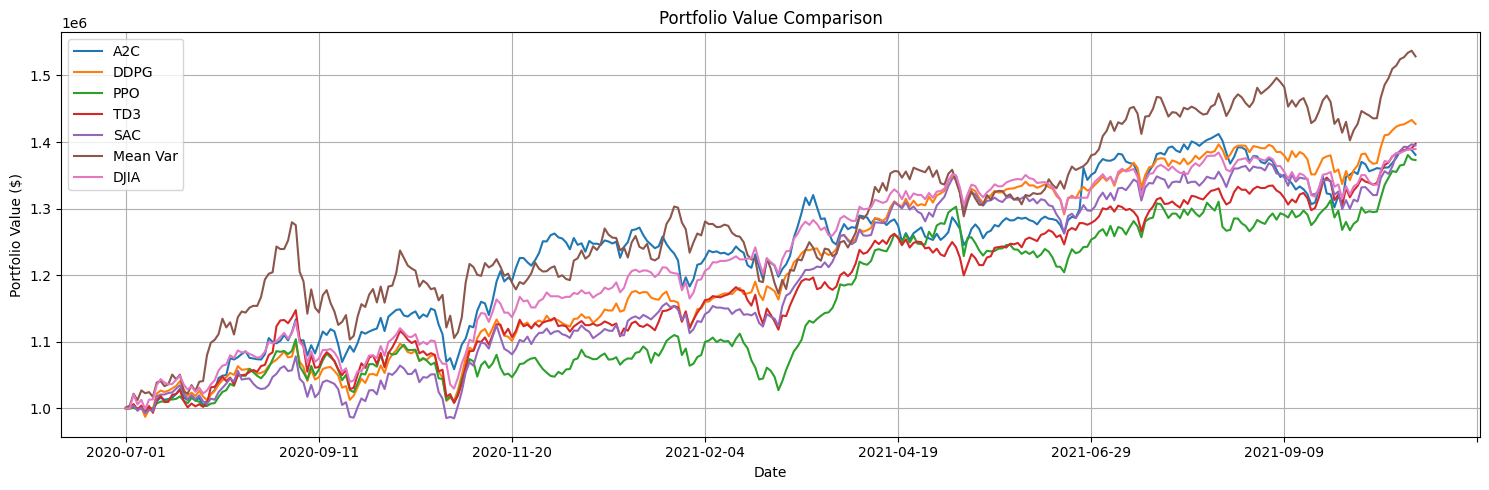

[SUCCESS] Phase 3.10: 결과 시각화 완료


In [37]:
# 결과 시각화
log_progress(3, 10, "RUNNING", "결과 시각화 중...")

plt.rcParams["figure.figsize"] = (15, 5)
plt.figure()
result.plot()
plt.title('Portfolio Value Comparison')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()

# 그래프 저장
try:
    os.makedirs('results', exist_ok=True)
    plt.savefig('results/backtest_comparison.png', dpi=300)
    print("\n그래프 저장: results/backtest_comparison.png")
except Exception as e:
    print(f"그래프 저장 실패: {str(e)}")

plt.show()

log_progress(3, 10, "SUCCESS", "결과 시각화 완료")

In [38]:
# 최종 수익률 계산
print("\n=== 최종 성과 요약 ===")
print(f"초기 자본금: $1,000,000\n")

for col in result.columns:
    initial_value = 1000000
    final_value = result[col].iloc[-1]
    total_return = (final_value - initial_value) / initial_value * 100

    print(f"{col}:")
    print(f"  최종 자산: ${final_value:,.2f}")
    print(f"  총 수익률: {total_return:.2f}%")
    print()


=== 최종 성과 요약 ===
초기 자본금: $1,000,000

A2C:
  최종 자산: $1,380,693.30
  총 수익률: 38.07%

DDPG:
  최종 자산: $1,427,186.70
  총 수익률: 42.72%

PPO:
  최종 자산: $1,372,867.41
  총 수익률: 37.29%

TD3:
  최종 자산: $1,397,476.02
  총 수익률: 39.75%

SAC:
  최종 자산: $1,394,870.67
  총 수익률: 39.49%

Mean Var:
  최종 자산: $1,528,607.74
  총 수익률: 52.86%

DJIA:
  최종 자산: $1,389,426.79
  총 수익률: 38.94%



In [39]:
# 결과 CSV 저장
try:
    result.to_csv('results/backtest_results.csv')
    print("결과 저장: results/backtest_results.csv")
    log_progress(3, 11, "SUCCESS", "결과 저장 완료")
except Exception as e:
    error_msg = f"결과 저장 실패: {str(e)}"
    print(error_msg)
    log_progress(3, 11, "ERROR", error_msg)

결과 저장: results/backtest_results.csv
[SUCCESS] Phase 3.11: 결과 저장 완료


## 완료!

백테스팅이 완료되었습니다.

**생성된 파일:**
- `results/backtest_comparison.png`: 성과 비교 그래프
- `results/backtest_results.csv`: 백테스팅 결과 데이터
- `PROGRESS_LOG.md`: 전체 실행 로그

**다음 단계:**
- 결과를 분석하고 개선 방향을 탐색하세요
- 다른 하이퍼파라미터로 재학습을 시도하세요
- 다른 기간의 데이터로 테스트하세요

In [40]:
# 최종 요약
log_progress(0, 0, "COMPLETED", "전체 FinRL Tutorial 완료")

print("\n" + "="*60)
print("백테스팅 완료!")
print("="*60)
print(f"\n모든 작업이 완료되었습니다!")
print(f"\n생성된 파일:")
print(f"  - train_data.csv / trade_data.csv (데이터)")
print(f"  - trained_models/ (학습된 모델)")
print(f"  - results/ (백테스팅 결과)")
print(f"  - PROGRESS_LOG.md (실행 로그)")
print("="*60)

[COMPLETED] Phase 0.0: 전체 FinRL Tutorial 완료

백테스팅 완료!

모든 작업이 완료되었습니다!

생성된 파일:
  - train_data.csv / trade_data.csv (데이터)
  - trained_models/ (학습된 모델)
  - results/ (백테스팅 결과)
  - PROGRESS_LOG.md (실행 로그)
